# Bodrum Hotel & Destination Intelligence
## 19 - Trip.com Hotel Policies & Amenities Enrichment

In [1]:

import sys, subprocess
sys.path.insert(0, r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews\src")
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\policies"
os.makedirs(FIG_DIR, exist_ok=True)

result = subprocess.run([sys.executable, REPO_ROOT + r"\scripts\analysis\build_policies_features_and_reports.py"],
                         capture_output=True, text=True, cwd=REPO_ROOT)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\data\processed\hotel_policies_features.csv (95 hotels)
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\tripcom_policies_coverage.csv
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\tripcom_policies_quality.csv
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\tripcom_amenity_frequency.csv
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\tripcom_policies_summary.txt



In [2]:

from bodrum_intelligence.reviews.common import master_hotel_csv_path
policy = pd.read_csv(REPO_ROOT + r"\data\processed\hotel_policies_features.csv")
master = pd.read_csv(master_hotel_csv_path())
google_profile = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_profile_summary.csv")
trip_profile = pd.read_csv(REPO_ROOT + r"\reports\tripcom_hotel_profile_summary.csv")
print("policy hotels:", len(policy), "| master hotels:", len(master))
policy.head(3)


policy hotels: 95 | master hotels: 192


,hotel_id,hotel_name,area,policy_status,has_checkin,has_checkout,has_children_policy,has_extra_bed_policy,has_breakfast_policy,has_pet_policy,...,has_parking,has_tennis,has_diving,has_snorkeling,has_childcare,has_conference_room,amenity_count,family_feature_count,wellness_feature_count,water_feature_count
0,BOD002,Armonia Holiday Village & Spa,Akyarlar,PARTIAL,True,True,True,True,False,True,...,False,True,False,False,True,False,11,4,3,1
1,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,PARTIAL,True,False,True,True,False,True,...,True,False,False,True,False,False,3,1,0,1
2,BOD004,Bendis Beach Hotel,Akyarlar,PARTIAL,True,False,True,True,True,True,...,True,True,True,False,False,False,12,3,3,2


## F2: Coverage

In [3]:

coverage = {
    "master_hotel_count": len(master),
    "hotels_with_policy_data": len(policy),
    "coverage_pct": round(len(policy) / len(master) * 100, 1),
}
print(coverage)
policy["policy_status"].value_counts()


{'master_hotel_count': 192, 'hotels_with_policy_data': 95, 'coverage_pct': 49.5}


policy_status
PARTIAL     94
COMPLETE     1
Name: count, dtype: int64

## F3: Amenity frequency

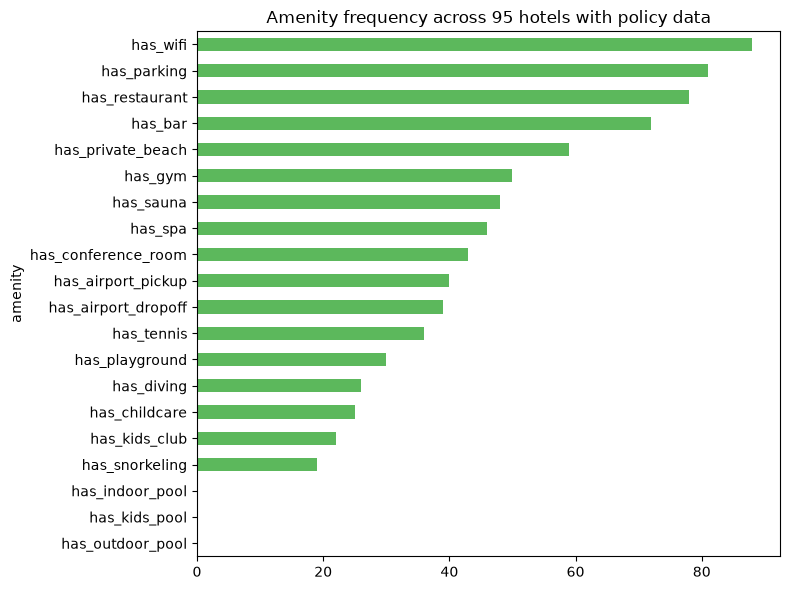

In [4]:

amenity_freq = pd.read_csv(REPO_ROOT + r"\reports\tripcom_amenity_frequency.csv")
fig, ax = plt.subplots(figsize=(8,6))
amenity_freq.set_index("amenity")["hotel_count"].sort_values().plot(kind="barh", ax=ax, color="#5cb85c")
ax.set_title(f"Amenity frequency across {len(policy)} hotels with policy data")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\amenity_frequency.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Her çubuk bir amenity'nin (olanak) kaç otelde ham metinde gerçekten geçtiğini gösterir.
### Ne görüyoruz?
En yaygın ve en nadir olanaklar.
### Neden önemli?
Aile/wellness/plaj odaklı otel profillemesi için temel veri.
### Dikkat edilmesi gereken nokta
Payda yalnızca policy verisi OLAN oteldir (14-20 civarı), 192 değil - coverage_pct'ye dikkat.

## F4: Area x amenity (covered hotels only)

In [5]:

area_amenity = policy.merge(master[["hotel_id","area"]], on="hotel_id", how="left", suffixes=("","_master"))
amenity_cols = [c for c in policy.columns if c.startswith("has_") and c not in
                ["has_checkin","has_checkout","has_children_policy","has_extra_bed_policy",
                 "has_breakfast_policy","has_pet_policy","has_service_animal_policy","has_age_rule","has_license","has_facilities"]]
area_summary = area_amenity.groupby("area")[amenity_cols].sum()
area_summary["covered_hotel_count"] = area_amenity.groupby("area").size()
area_summary.head(10)


,has_private_beach,has_indoor_pool,has_outdoor_pool,has_kids_pool,has_kids_club,has_playground,has_spa,has_sauna,has_gym,has_restaurant,...,has_wifi,has_airport_pickup,has_airport_dropoff,has_parking,has_tennis,has_diving,has_snorkeling,has_childcare,has_conference_room,covered_hotel_count
area,,,,,,,,,,,,,,,,,,,,,
Akyarlar,6,0,0,0,4,6,8,7,8,9,...,11,5,4,9,6,4,4,2,5,11
Bitez,3,0,0,0,1,2,2,2,3,5,...,5,4,4,5,4,1,1,1,2,7
Bodrum Merkez,3,0,0,0,1,1,3,3,4,4,...,4,3,3,4,2,3,1,1,4,4
Göltürkbükü,4,0,0,0,1,1,1,1,1,4,...,4,3,3,3,1,1,1,2,2,4
Gümbet,5,0,0,0,1,3,2,4,4,8,...,8,2,2,7,4,0,0,1,4,9
Gümüşlük,0,0,0,0,0,0,0,0,0,4,...,7,3,3,6,1,1,2,0,1,8
Gündoğan,5,0,0,0,2,3,5,5,5,6,...,8,5,5,7,2,1,1,3,5,8
Güvercinlik,5,0,0,0,4,4,3,3,4,5,...,5,1,1,4,4,3,1,4,4,5
Kadıkalesi,2,0,0,0,2,2,2,2,2,2,...,2,0,0,2,2,2,0,1,2,2


## F5-F7: Family-friendly / Wellness / Beach-water features

In [6]:

feature_summary = policy[["family_feature_count","wellness_feature_count","water_feature_count"]].describe()
feature_summary


,family_feature_count,wellness_feature_count,water_feature_count
count,95.000000,95.000000,95.000000
mean,1.810526,1.515789,1.094737
std,1.141991,1.382744,0.957320
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,2.000000,1.000000
75%,2.000000,3.000000,1.500000
max,4.000000,3.000000,3.000000


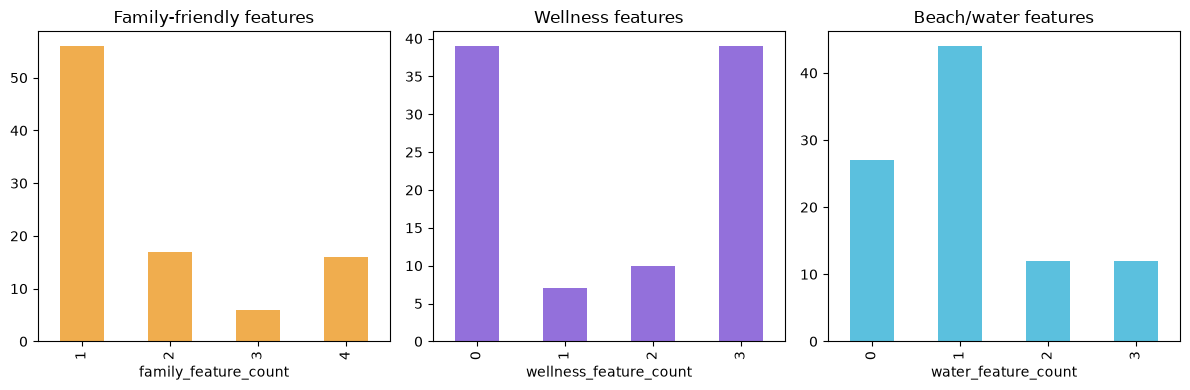

In [7]:

fig, axes = plt.subplots(1,3, figsize=(12,4))
for ax, col, title, color in zip(axes,
    ["family_feature_count","wellness_feature_count","water_feature_count"],
    ["Family-friendly features","Wellness features","Beach/water features"],
    ["#f0ad4e","#9370db","#5bc0de"]):
    policy[col].value_counts().sort_index().plot(kind="bar", ax=ax, color=color, title=title)
plt.tight_layout()
plt.savefig(FIG_DIR + r"\feature_group_distributions.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Her panel bir özellik grubunun (aile/wellness/plaj-su) otel başına kaç madde içerdiğini gösterir.
### Ne görüyoruz?
Politika verisi olan otellerin bu üç boyuttaki donanım zenginliği.
### Neden önemli?
Aile/wellness/plaj odaklı arketip oluşturmanın (notebook 20) girdisi.
### Dikkat edilmesi gereken nokta
Yalnızca raw `hizmetler` metninde gerçekten geçen ifadelerden türetilmiştir; tahmin yoktur.

## F8: Policy + Customer Voice association (exploratory, NOT causal)

In [8]:

merged = policy.merge(trip_profile[["hotel_id","n","mean_rating_5" if "mean_rating_5" in trip_profile.columns else "mean_rating_5"]],
                       on="hotel_id", how="left") if "mean_rating_5" in trip_profile.columns else policy.merge(
    trip_profile.rename(columns={"n":"trip_n"})[["hotel_id","trip_n"]], on="hotel_id", how="left")
has_kids_club_hotels = policy[policy["has_kids_club"]]["hotel_id"].tolist()
has_spa_hotels = policy[policy["has_spa"]]["hotel_id"].tolist()
print(f"{len(has_kids_club_hotels)} hotels advertise a kids club; {len(has_spa_hotels)} advertise a spa.")
print("Association exploration only - no causal claim.")


22 hotels advertise a kids club; 46 advertise a spa.
Association exploration only - no causal claim.


## F9: Output - hotel_policy_customer_voice_enriched.csv

In [9]:

g = google_profile.set_index("hotel_id")[["n_reviews","mean_rating"]].rename(
    columns={"n_reviews":"google_review_n","mean_rating":"google_rating"})
t = trip_profile.set_index("hotel_id")
t_cols = {"n":"trip_review_n"}
if "mean_rating_5" in t.columns:
    t_cols["mean_rating_5"] = "trip_rating"
t = t.rename(columns=t_cols)[[c for c in t_cols.values() if c in t.rename(columns=t_cols).columns]]

enriched = policy.set_index("hotel_id")[
    ["hotel_name","area","amenity_count","family_feature_count","wellness_feature_count","water_feature_count"]
].rename(columns={"family_feature_count":"family_feature_count","wellness_feature_count":"wellness_feature_count"})
enriched["policy_coverage"] = policy.set_index("hotel_id")["policy_status"]
enriched = enriched.join([g, t], how="outer")
enriched["source_count"] = enriched[["google_review_n","trip_review_n"]].notna().sum(axis=1)
enriched["support"] = enriched["source_count"].map({0:"NO_DATA",1:"SINGLE_SOURCE",2:"MULTI_SOURCE"})
enriched = enriched.reset_index().rename(columns={"index":"hotel_id"})
enriched.to_csv(REPO_ROOT + r"\reports\hotel_policy_customer_voice_enriched.csv", index=False)
print(len(enriched), "hotels in enriched output")
enriched.head(10)


142 hotels in enriched output


,hotel_id,hotel_name,area,amenity_count,family_feature_count,wellness_feature_count,water_feature_count,policy_coverage,google_review_n,google_rating,trip_review_n,trip_rating,source_count,support
0,BOD001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,5.000000,NaN,NaN,1,SINGLE_SOURCE
1,BOD002,Armonia Holiday Village & Spa,Akyarlar,11.0,4.0,3.0,1.0,PARTIAL,10.0,3.600000,11.0,3.818182,2,MULTI_SOURCE
2,BOD003,ASPAT HOTEL BODRUM Beach Restaurant,Akyarlar,3.0,1.0,0.0,1.0,PARTIAL,30.0,4.433333,28.0,3.678571,2,MULTI_SOURCE
3,BOD004,Bendis Beach Hotel,Akyarlar,12.0,3.0,3.0,2.0,PARTIAL,10.0,2.000000,11.0,3.954545,2,MULTI_SOURCE
4,BOD005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,4.600000,NaN,NaN,1,SINGLE_SOURCE
5,BOD006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,4.300000,NaN,NaN,1,SINGLE_SOURCE
6,BOD007,Kefaluka Resort,Akyarlar,15.0,4.0,3.0,3.0,PARTIAL,60.0,4.066667,11.0,4.259091,2,MULTI_SOURCE
7,BOD008,LA BREZZA SUITE &HOTEL,Akyarlar,7.0,2.0,0.0,0.0,PARTIAL,20.0,5.000000,11.0,4.009091,2,MULTI_SOURCE
8,BOD010,Mare Garden Hotel,Akyarlar,8.0,1.0,0.0,3.0,PARTIAL,10.0,3.200000,2.0,4.000000,2,MULTI_SOURCE
9,BOD011,"Radisson Collection Hotel, Bodrum",Akyarlar,11.0,1.0,3.0,1.0,PARTIAL,10.0,4.800000,11.0,4.750000,2,MULTI_SOURCE


## F10: Notebook 19 - Key Findings

In [10]:

findings = []
findings.append(f"{len(policy)}/{len(master)} master hotels ({coverage['coverage_pct']}%) have any Trip.com policy data.")
findings.append(f"Most common amenity: {amenity_freq.iloc[0]['amenity']} ({amenity_freq.iloc[0]['hotel_count']} hotels).")
findings.append(f"{len(has_kids_club_hotels)} hotels advertise a kids club (family-friendly signal).")
findings.append(f"{len(has_spa_hotels)} hotels advertise a spa (wellness signal).")
findings.append(f"Mean amenity_count across covered hotels: {round(policy['amenity_count'].mean(),1)}.")
findings.append("Checkout time coverage remains the weakest policy field - a known site-side gap, not a scraper bug.")
findings.append("Policy-vs-rating associations above are exploratory only - sample sizes are too small for causal claims.")
for i, f_ in enumerate(findings, 1):
    print(f"{i}. {f_}")


1. 95/192 master hotels (49.5%) have any Trip.com policy data.
2. Most common amenity: has_wifi (88 hotels).
3. 22 hotels advertise a kids club (family-friendly signal).
4. 46 hotels advertise a spa (wellness signal).
5. Mean amenity_count across covered hotels: 8.4.
6. Checkout time coverage remains the weakest policy field - a known site-side gap, not a scraper bug.
7. Policy-vs-rating associations above are exploratory only - sample sizes are too small for causal claims.
